
# Nigerian Hate Speech Model — Evaluation & Visualization Notebook

This notebook evaluates the **OptimizedNigerianHateSpeechDetector** from your Flask app.  
It will:
- Load your detector (from the same folder as this notebook)  
- Train (or load) the model  
- Produce **evaluation metrics** (accuracy, precision, recall, F1, ROC-AUC where available)  
- Generate **visualizations**: confusion matrix, ROC curve, Precision–Recall curve, calibration curve  
- Show **feature insights** (top positive/negative coefficients)  
- Run **Nigerian-specific test examples** and report accuracy  
- Save a small `metrics_summary.json` for reference

> **Requirements:**  
> - Run this notebook in the **same directory** where your Flask code lives (so the class is importable), or update the import path below.  
> - For training from Kaggle you need valid Kaggle credentials configured (`~/.kaggle/kaggle.json` or env vars).


In [1]:

import os, sys, json, time, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

# sklearn metrics
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, auc, brier_score_loss
)

# Make plots a bit crisper
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)



## 1) Import your detector

We try to import `OptimizedNigerianHateSpeechDetector` from your app module.  
- If your file is named differently (e.g., `main.py`), update the import.  
- Ensure the notebook runs in the same directory as your code.


In [2]:

# Try common filenames; adjust if needed
possible_modules = ['app', 'main', 'server']
detector_cls = None

for mod in possible_modules:
    try:
        m = __import__(mod)
        if hasattr(m, 'OptimizedNigerianHateSpeechDetector'):
            detector_cls = getattr(m, 'OptimizedNigerianHateSpeechDetector')
            print(f"Imported OptimizedNigerianHateSpeechDetector from '{mod}.py'")
            break
    except Exception as e:
        # Try adding current folder to path and retry
        sys.path.append(str(Path('.').resolve()))
        try:
            m = __import__(mod)
            if hasattr(m, 'OptimizedNigerianHateSpeechDetector'):
                detector_cls = getattr(m, 'OptimizedNigerianHateSpeechDetector')
                print(f"Imported OptimizedNigerianHateSpeechDetector from '{mod}.py'")
                break
        except Exception as e2:
            pass

if detector_cls is None:
    raise ImportError("Could not find 'OptimizedNigerianHateSpeechDetector' in app.py/main.py/server.py. "
                      "Please update the import cell to point to your file.")


INFO:app:Kaggle API authenticated successfully


Imported OptimizedNigerianHateSpeechDetector from 'app.py'



## 2) Load or Train the Model
- We first try to **load an existing** `nigerian_hate_speech_model.pkl` if present.  
- If not found, we call the detector's `train_optimized_model()` (requires Kaggle access).


In [3]:

detector = detector_cls()

loaded = detector.load_model()
if loaded:
    print("Loaded existing model from 'nigerian_hate_speech_model.pkl'")
else:
    print("No pre-saved model found. Starting training...")
    metrics = detector.train_optimized_model()
    if 'error' in metrics:
        print("Training error:", metrics['error'])
    else:
        print("Training completed.")


INFO:app:Kaggle API authenticated successfully
INFO:app:Model loaded successfully


Loaded existing model from 'nigerian_hate_speech_model.pkl'



## 3) Model Metrics Snapshot
This shows the metrics that your detector stored internally after training.


In [4]:

snapshot = detector.get_performance_metrics()
print(json.dumps(snapshot, indent=2))


{
  "performance_metrics": {
    "accuracy": 0.7197197197197197,
    "precision": 0.7197205364005038,
    "recall": 0.7197197197197197,
    "f1": 0.7197188459852734,
    "confusion_matrix": [
      [
        1075,
        422
      ],
      [
        418,
        1082
      ]
    ],
    "training_samples": 14981,
    "test_samples": 2997,
    "vocabulary_size": 3000,
    "auc_roc": 0.8007704297483856
  },
  "model_status": {
    "trained": true,
    "training_in_progress": false,
    "model_version": "optimized_nigerian_v1",
    "specialized_for": "Nigerian hate speech detection"
  },
  "configuration": {
    "max_features": 3000,
    "max_samples": 15000,
    "use_ensemble": false
  }
}



## 4) Visual Evaluation on Holdout Set

We re-run a small evaluation using the detector's stored split (if available).  
> If the notebook cannot access the original holdout, we will perform a quick re-split from the vectorized texts captured during this run.  
**Plots below:** Confusion Matrix, ROC Curve (if binary), Precision–Recall Curve, Calibration (Reliability) Curve.


INFO:app:Downloading dataset: sharonibejih/nigerian-multilingual-hate-speech


Dataset URL: https://www.kaggle.com/datasets/sharonibejih/nigerian-multilingual-hate-speech


INFO:app:Found CSV files: ['./nigerian_multilingual_dataset\\multilingual_hate_speech_dataset.csv']
INFO:app:Function: download_dataset - Duration: 5.35s - Success: True
INFO:app:Loaded ./nigerian_multilingual_dataset\multilingual_hate_speech_dataset.csv with utf-8 encoding
INFO:app:Dataset shape: (27148, 3)
INFO:app:Columns: ['class', 'text', 'language']
INFO:app:Using text column: text, label column: class
INFO:app:Final dataset shape: (15000, 3)
INFO:app:Label distribution: {0: 7500, 1: 7500}
INFO:app:Function: load_and_process_dataset - Duration: 6.09s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration:

Eval dataset shape: (15000, 3)


INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_tex

Accuracy: 0.7197 | Precision: 0.7197 | Recall: 0.7197 | F1: 0.7197


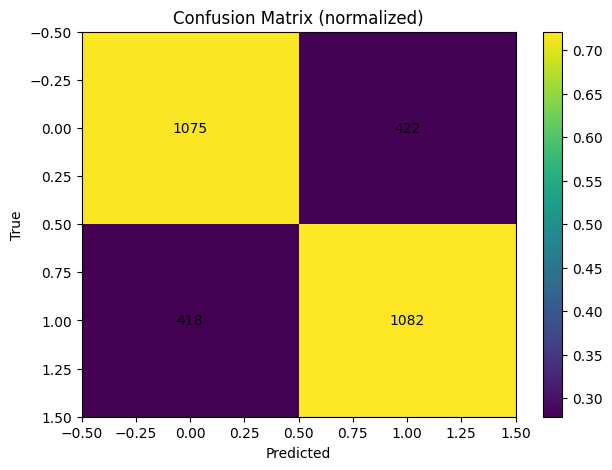

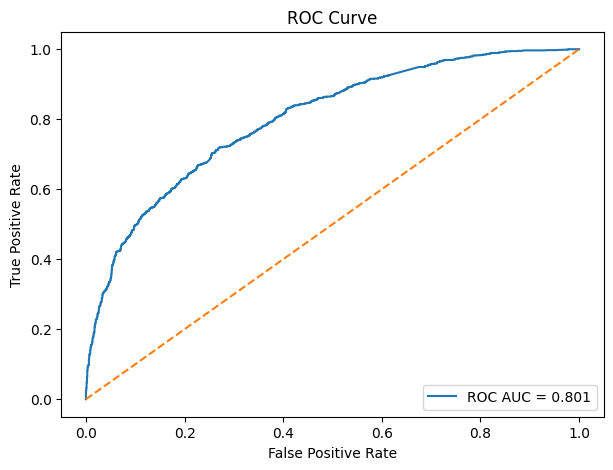

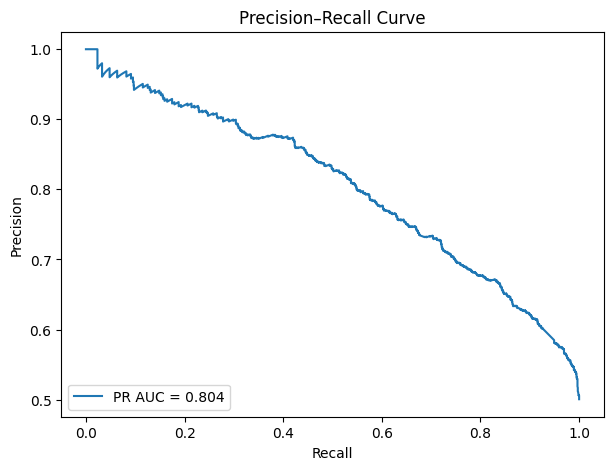

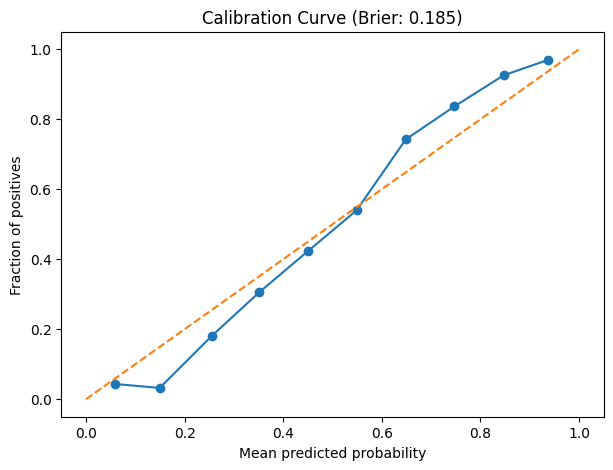

Saved metrics_summary.json


In [5]:

# We can't directly access X_test, y_test from inside the detector,
# so we'll reconstruct a quick evaluation by reloading the dataset and vectorizing locally.

def safe_load_processed(det):
    df = det.load_and_process_dataset()
    if df is None or df.empty:
        raise RuntimeError("Could not reload dataset for evaluation.")
    return df

try:
    df_eval = safe_load_processed(detector)
    print(f"Eval dataset shape: {df_eval.shape}")
except Exception as e:
    raise RuntimeError(f"Dataset reload failed: {e}")

# Preprocess texts
texts = []
labels = []
for _, row in df_eval.iterrows():
    t = detector.fast_preprocess_text(row['text'])
    if t:
        texts.append(t)
        labels.append(int(row['label']))

from sklearn.model_selection import train_test_split
X = detector.vectorizer.fit_transform(texts)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Refit model for this local eval
detector.model.fit(X_train, y_train)

y_pred = detector.model.predict(X_test)
if hasattr(detector.model, "predict_proba"):
    y_prob = detector.model.predict_proba(X_test)[:, 1]
else:
    # decision_function fallback (SVM); rescale to 0-1 with a logistic function
    scores = detector.model.decision_function(X_test)
    y_prob = 1/(1+np.exp(-scores))

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig = plt.figure()
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Confusion Matrix (normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i,j]}", ha="center", va="center")
plt.colorbar()
plt.show()

# ROC Curve (binary only)
try:
    roc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fig = plt.figure()
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()
except Exception as e:
    print("ROC curve not available:", e)

# Precision–Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rec_curve, prec_curve)
fig = plt.figure()
plt.plot(rec_curve, prec_curve, label=f"PR AUC = {pr_auc:.3f}")
plt.title('Precision–Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

# Calibration (Reliability) curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_test, y_prob)
fig = plt.figure()
plt.plot(prob_pred, prob_true, marker='o', linestyle='-')
plt.plot([0,1],[0,1],'--')
plt.title(f'Calibration Curve (Brier: {brier:.3f})')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.show()

# Save summary
summary = {
    "timestamp": datetime.now().isoformat(),
    "samples": int(len(y_test)),
    "accuracy": float(acc),
    "precision_weighted": float(prec),
    "recall_weighted": float(rec),
    "f1_weighted": float(f1),
    "roc_auc": float(roc) if 'roc' in locals() else None,
    "pr_auc": float(pr_auc),
    "brier_score": float(brier),
    "confusion_matrix": cm.tolist()
}
with open("metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved metrics_summary.json")



## 5) Feature Insights (Top Tokens)

For linear models like Logistic Regression, we can inspect the top coefficients.


Top tokens pushing towards HATE (positive class):
nzuzu                 4.9074
mumu                  4.7312
stupid                4.0066
wauta                 3.6834
fuck                  3.5680
useless               3.4365
bitches               3.3111
idiot                 3.2952
shit                  3.2140
wawa                  3.1727
hoes                  3.0974
nonsense              2.8986
fool                  2.8933
evil                  2.8645
iberibe               2.8634
hoe                   2.8037
bitch                 2.7495
fucking               2.7225
ass                   2.6351
bastards              2.5834

Top tokens pushing towards NON-HATE (negative class):
kike                 -3.2151
nyamiri              -1.9680
link                 -1.8488
owo                  -1.6907
arne                 -1.5973
sef                  -1.5873
gt                   -1.5872
allah                -1.5540
arsenal              -1.5177
bro                  -1.4765
kim                  -1.4

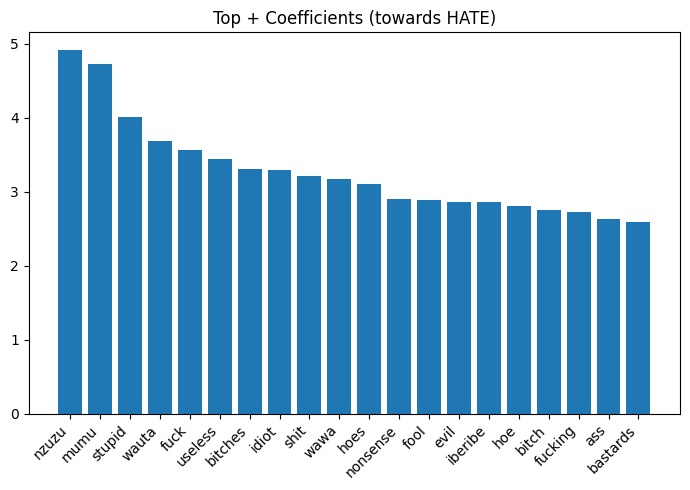

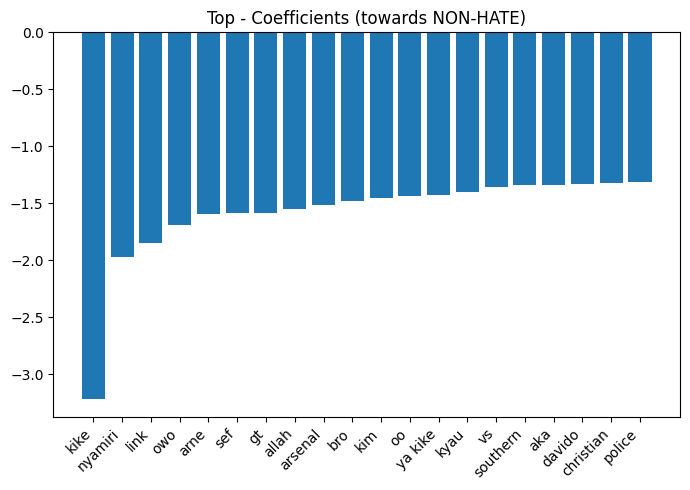

In [6]:

if hasattr(detector.model, 'coef_') and detector.model.coef_.ndim == 2:
    feature_names = np.array(detector.vectorizer.get_feature_names_out())
    coefs = detector.model.coef_[0]

    top_pos_idx = np.argsort(coefs)[-20:][::-1]
    top_neg_idx = np.argsort(coefs)[:20]

    top_pos = list(zip(feature_names[top_pos_idx], coefs[top_pos_idx]))
    top_neg = list(zip(feature_names[top_neg_idx], coefs[top_neg_idx]))

    print("Top tokens pushing towards HATE (positive class):")
    for tok, w in top_pos:
        print(f"{tok:20s} {w: .4f}")

    print("\nTop tokens pushing towards NON-HATE (negative class):")
    for tok, w in top_neg:
        print(f"{tok:20s} {w: .4f}")

    # Simple bar plot for top positive and negative tokens
    fig = plt.figure()
    plt.bar(range(len(top_pos)), [w for _, w in top_pos])
    plt.xticks(range(len(top_pos)), [t for t,_ in top_pos], rotation=45, ha='right')
    plt.title('Top + Coefficients (towards HATE)')
    plt.tight_layout()
    plt.show()

    fig = plt.figure()
    plt.bar(range(len(top_neg)), [w for _, w in top_neg])
    plt.xticks(range(len(top_neg)), [t for t,_ in top_neg], rotation=45, ha='right')
    plt.title('Top - Coefficients (towards NON-HATE)')
    plt.tight_layout()
    plt.show()
else:
    print("Model coefficients not available for feature introspection.")



## 6) Nigerian-Specific Test Examples


INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_tex

Test Accuracy on curated examples: 0.850 (17/20)


,text,expected,predicted,confidence,hate_probability,correct
0,You are a useless mumu person,Hate,Hate Speech,0.979139,0.950000,True
1,This yeye government is nonsense,Not Hate,Hate Speech,0.873675,0.900000,False
2,All yoruba people are thieves,Hate,Hate Speech,0.544372,0.544372,True
3,I will kill you bastard,Hate,Hate Speech,0.790480,0.950000,True
4,You oloshi go die there,Hate,Hate Speech,0.765405,0.950000,True
5,Werey person like you,Hate,Hate Speech,0.769450,0.869450,True
6,This ashawo no get sense,Hate,Hate Speech,0.799036,0.899036,True
7,You be bloody fool,Hate,Hate Speech,0.870923,0.950000,True
8,Go hug transformer,Hate,Not Hate Speech,0.674036,0.325964,False
9,Mad person like you,Hate,Hate Speech,0.745643,0.845643,True


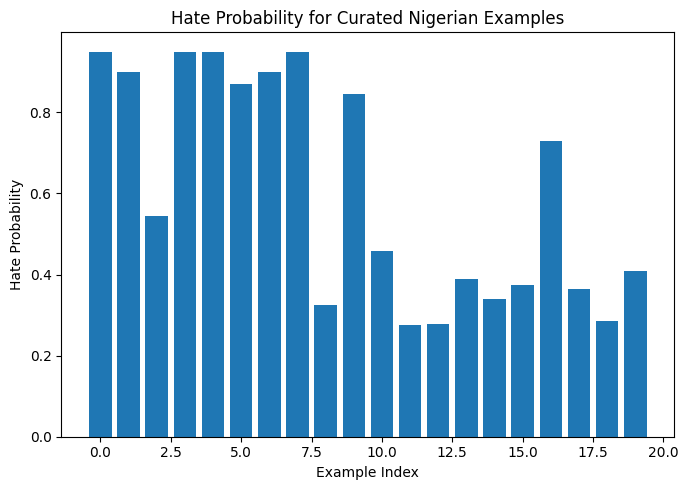

In [7]:

try:
    test_out = detector.test_nigerian_examples()
    print(f"Test Accuracy on curated examples: {test_out['accuracy']:.3f} "
          f"({test_out['correct_predictions']})")

    # Display as DataFrame
    df_test = pd.DataFrame(test_out['test_results'])
    display(df_test)

    # Quick bar plot of hate_probability for visualization
    fig = plt.figure()
    plt.bar(range(len(df_test)), df_test['hate_probability'])
    plt.title('Hate Probability for Curated Nigerian Examples')
    plt.xlabel('Example Index')
    plt.ylabel('Hate Probability')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Could not run curated Nigerian examples:", e)



## 7) Inference Latency (Micro-bench)


INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True
INFO:app:Function: fast_preprocess_text - Duration: 0.00s - Success: True


,text,latency_sec
0,You are a useless mumu person,0.006230
1,I love Nigeria and its people,0.004520
2,This yeye government is nonsense,0.004999
3,Go hug transformer,0.004652
4,We should all live together in peace,0.005017


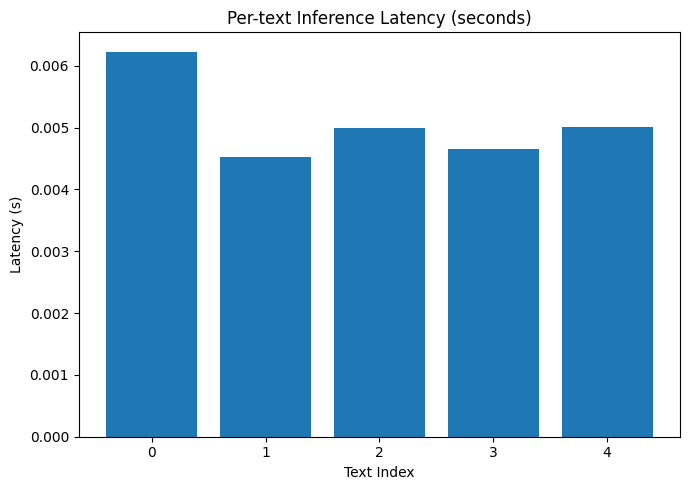

Avg latency: 0.0051s | P95: 0.0060s


In [8]:

sample_texts = [
    "You are a useless mumu person",
    "I love Nigeria and its people",
    "This yeye government is nonsense",
    "Go hug transformer",
    "We should all live together in peace"
]

times = []
for t in sample_texts:
    start = time.time()
    _ = detector.predict(t)
    times.append(time.time() - start)

lat_df = pd.DataFrame({"text": sample_texts, "latency_sec": times})
display(lat_df)

fig = plt.figure()
plt.bar(range(len(times)), times)
plt.title('Per-text Inference Latency (seconds)')
plt.xlabel('Text Index')
plt.ylabel('Latency (s)')
plt.tight_layout()
plt.show()

print(f"Avg latency: {np.mean(times):.4f}s | P95: {np.percentile(times,95):.4f}s")



## 8) Optional: Save HTML Report
Run this cell if you want a quick static report of the metrics snapshot and summary.


In [9]:

try:
    from pathlib import Path
    snapshot = detector.get_performance_metrics()
    summary = {}
    if Path('metrics_summary.json').exists():
        summary = json.load(open('metrics_summary.json'))
    html = f"""
    <h2>Nigerian Hate Speech Model — Report</h2>
    <p><b>Generated:</b> {datetime.now().isoformat()}</p>
    <h3>Snapshot</h3>
    <pre>{json.dumps(snapshot, indent=2)}</pre>
    <h3>Summary</h3>
    <pre>{json.dumps(summary, indent=2)}</pre>
    """
    with open("evaluation_report.html", "w", encoding="utf-8") as f:
        f.write(html)
    print("Saved evaluation_report.html")
except Exception as e:
    print("Could not save HTML report:", e)


Saved evaluation_report.html



---

**Done.**  
If anything fails (e.g., Kaggle access), adjust the import path, ensure credentials, and re-run.
